In [275]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import matplotlib.cm as cm
import scipy 

from tqdm import tqdm

import emcee
import corner

# # import marvin
# import pyneb as pn
# import sys
# sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
# from elliptical_plottingFunctions import *
# from IO_data import *
# from elliptical_stellar_mass import calc_mass_curve
# from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
# from matplotlib.lines import Line2D

# from scipy.optimize import curve_fit
# from scipy.optimize import minimize
# import scipy.stats as stats

# sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/spirals')
# from SHMR_functions import shmr_RP11

In [276]:
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [277]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v11_gradZ.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

In [278]:
def metallicity_from_grad(r, z0, grad_z):
    # r in kpc

    return z0 + grad_z*r

In [279]:

H_0 = 100      # Hubble's Constant in units of h km/s/Mpc
c = 299792.458 # Speed of light in units of km/s
# arcsec to rad
R90_rad = master_table['nsa_elpetro_th90']*(1/60)*(1/60)*(np.pi/180)
dist_to_gal_Mpc = c*master_table['nsa_z']/H_0
dist_to_gal_kpc = dist_to_gal_Mpc*1000

R90_kpc = dist_to_gal_kpc*np.tan(R90_rad)

In [280]:
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'

p3d = Table.read(DATA_FOLDER + 'SDSS17Pipe3D_v3_1_1.fits', format='fits')
p3d[:5]

name,plate,ifudsgn,plateifu,mangaid,objra,objdec,log_SFR_Ha,FoV,Re_kpc,e_log_Mass,e_log_SFR_Ha,log_Mass,log_SFR_ssp,log_NII_Ha_cen,e_log_NII_Ha_cen,log_OIII_Hb_cen,e_log_OIII_Hb_cen,log_SII_Ha_cen,e_log_SII_Ha_cen,log_OII_Hb_cen,e_log_OII_Hb_cen,EW_Ha_cen,e_EW_Ha_cen,ZH_LW_Re_fit,e_ZH_LW_Re_fit,alpha_ZH_LW_Re_fit,e_alpha_ZH_LW_Re_fit,ZH_MW_Re_fit,e_ZH_MW_Re_fit,alpha_ZH_MW_Re_fit,e_alpha_ZH_MW_Re_fit,Age_LW_Re_fit,e_Age_LW_Re_fit,alpha_Age_LW_Re_fit,e_alpha_Age_LW_Re_fit,Age_MW_Re_fit,e_Age_MW_Re_fit,alpha_Age_MW_Re_fit,e_alpha_Age_MW_Re_fit,Re_arc,DL,DA,PA,ellip,log_Mass_gas,vel_sigma_Re,e_vel_sigma_Re,log_SFR_SF,log_SFR_D_C,OH_O3N2_cen,e_OH_O3N2_cen,OH_N2_cen,e_OH_N2_cen,OH_ONS_cen,e_OH_ONS_cen,OH_R23_cen,e_OH_R23_cen,OH_pyqz_cen,e_OH_pyqz_cen,OH_t2_cen,e_OH_t2_cen,OH_M08_cen,e_OH_M08_cen,OH_T04_cen,e_OH_T04_cen,OH_dop_cen,e_OH_dop_cen,OH_O3N2_EPM09_cen,e_OH_O3N2_EPM09_cen,log_OI_Ha_cen,e_log_OI_Ha_cen,Ha_Hb_cen,e_Ha_Hb_cen,log_NII_Ha_Re,e_log_NII_Ha_Re,log_OIII_Hb_Re,e_log_OIII_Hb_Re,log_SII_Ha_Re,e_log_SII_Ha_Re,log_OII_Hb_Re,e_log_OII_Hb_Re,log_OI_Ha_Re,e_log_OI_Ha_Re,EW_Ha_Re,e_EW_Ha_Re,Ha_Hb_Re,e_Ha_Hb_Re,log_NII_Ha_ALL,e_log_NII_Ha_ALL,log_OIII_Hb_ALL,e_log_OIII_Hb_ALL,log_SII_Ha_ALL,e_log_SII_Ha_ALL,log_OII_Hb_ALL,e_log_OII_Hb_ALL,log_OI_Ha_ALL,e_log_OI_Ha_ALL,EW_Ha_ALL,e_EW_Ha_ALL,Ha_Hb_ALL,Sigma_Mass_cen,e_Sigma_Mass_cen,Sigma_Mass_Re,e_Sigma_Mass_Re,Sigma_Mass_ALL,e_Sigma_Mass_ALL,T30,ZH_T30,ZH_Re_T30,a_ZH_T30,T40,ZH_T40,ZH_Re_T40,a_ZH_T40,T50,ZH_T50,ZH_Re_T50,a_ZH_T50,T60,ZH_T60,ZH_Re_T60,a_ZH_T60,T70,ZH_T70,ZH_Re_T70,a_ZH_T70,T80,ZH_T80,ZH_Re_T80,a_ZH_T80,T90,ZH_T90,ZH_Re_T90,a_ZH_T90,T95,ZH_T95,ZH_Re_T95,a_ZH_T95,T99,ZH_T99,ZH_Re_T99,a_ZH_T99,log_Mass_gas_Av_gas_OH,log_Mass_gas_Av_ssp_OH,vel_ssp_2,e_vel_ssp_2,vel_Ha_2,e_vel_Ha_2,vel_ssp_1,e_vel_ssp_1,vel_Ha_1,e_vel_Ha_1,log_SFR_ssp_100Myr,log_SFR_ssp_10Myr,vel_disp_Ha_cen,vel_disp_ssp_cen,vel_disp_Ha_1Re,vel_disp_ssp_1Re,log_Mass_in_Re,ML_int,ML_avg,F_Ha_cen,e_F_Ha_cen,R50_kpc_V,e_R50_kpc_V,R50_kpc_Mass,e_R50_kpc_Mass,log_Mass_corr_in_R50_V,e_log_Mass_corr_in_R50_V,log_Mass_gas_Av_gas_log_log,Av_gas_Re,e_Av_gas_Re,Av_ssp_Re,e_Av_ssp_Re,Lambda_Re,e_Lambda_Re,nsa_redshift,nsa_mstar,nsa_inclination,flux_[OII]3726.03_Re_fit,e_flux_[OII]3726.03_Re_fit,flux_[OII]3726.03_alpha_fit,e_flux_[OII]3726.03_alpha_fit,flux_[OII]3728.82_Re_fit,e_flux_[OII]3728.82_Re_fit,flux_[OII]3728.82_alpha_fit,e_flux_[OII]3728.82_alpha_fit,flux_HI3734.37_Re_fit,e_flux_HI3734.37_Re_fit,flux_HI3734.37_alpha_fit,e_flux_HI3734.37_alpha_fit,flux_HI3797.9_Re_fit,e_flux_HI3797.9_Re_fit,flux_HI3797.9_alpha_fit,e_flux_HI3797.9_alpha_fit,flux_HeI3888.65_Re_fit,e_flux_HeI3888.65_Re_fit,flux_HeI3888.65_alpha_fit,e_flux_HeI3888.65_alpha_fit,flux_HI3889.05_Re_fit,e_flux_HI3889.05_Re_fit,flux_HI3889.05_alpha_fit,e_flux_HI3889.05_alpha_fit,flux_HeI3964.73_Re_fit,e_flux_HeI3964.73_Re_fit,flux_HeI3964.73_alpha_fit,e_flux_HeI3964.73_alpha_fit,flux_[NeIII]3967.46_Re_fit,e_flux_[NeIII]3967.46_Re_fit,flux_[NeIII]3967.46_alpha_fit,e_flux_[NeIII]3967.46_alpha_fit,flux_CaII3968.47_Re_fit,e_flux_CaII3968.47_Re_fit,flux_CaII3968.47_alpha_fit,e_flux_CaII3968.47_alpha_fit,flux_Hepsilon3970.07_Re_fit,e_flux_Hepsilon3970.07_Re_fit,flux_Hepsilon3970.07_alpha_fit,e_flux_Hepsilon3970.07_alpha_fit,flux_Hdelta4101.77_Re_fit,e_flux_Hdelta4101.77_Re_fit,flux_Hdelta4101.77_alpha_fit,e_flux_Hdelta4101.77_alpha_fit,flux_Hgamma4340.49_Re_fit,e_flux_Hgamma4340.49_Re_fit,flux_Hgamma4340.49_alpha_fit,e_flux_Hgamma4340.49_alpha_fit,flux_Hbeta4861.36_Re_fit,e_flux_Hbeta4861.36_Re_fit,flux_Hbeta4861.36_alpha_fit,e_flux_Hbeta4861.36_alpha_fit,flux_[OIII]4958.91_Re_fit,e_flux_[OIII]4958.91_Re_fit,flux_[OIII]4958.91_alpha_fit,e_flux_[OIII]4958.91_alpha_fit,flux_[OIII]5006.84_Re_fit,e_flux_[OIII]5006.84_Re_fit,flux_[OIII]5006.84_alpha_fit,e_flux_[OIII]5006.84_alpha_fit,flux_HeI5015.68_Re_fit,e_flux_HeI5015.68_Re_fit,flux_HeI5015.68_alpha_fit,e_flux_HeI5015.68_alpha_fit,flux_[NI]5197.9_Re_fit,e_flux_[NI]5197.9_Re_fit,flux_[NI]5197.9_alpha_fit

In [281]:
# add stellar metallicity and ages
p3d_dict = {}
for i in range(len(p3d)):
    p3d_dict[p3d[i]['plateifu']] = i


master_table['Age_LW_Re_fit'] = -99.
master_table['Age_MW_Re_fit'] = -99.
master_table['ZH_LW_Re_fit'] = -99.
master_table['ZH_MW_Re_fit'] = -99.

for i in range(len(master_table)):

    try:

        i_p = p3d_dict[master_table[i]['plateifu']]
        # print(i_p)
        
        master_table['Age_LW_Re_fit'][i] = p3d[i_p]['Age_LW_Re_fit']
        master_table['Age_MW_Re_fit'][i] = p3d[i_p]['Age_MW_Re_fit']
        master_table['ZH_LW_Re_fit'][i] = p3d[i_p]['ZH_LW_Re_fit']
        master_table['ZH_MW_Re_fit'][i] = p3d[i_p]['ZH_MW_Re_fit']
    
    except:
        # print(master_table[i]['plateifu'])
        continue

/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/astropy/table/column.py:1376: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value


### add kias params

In [282]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [283]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [284]:
master_table['kias_u_r'] = np.ones(len(master_table))*np.nan
master_table['kias_cinv'] = np.ones(len(master_table))*np.nan
master_table['kias_cd'] = np.ones(len(master_table))*np.nan

for i in range(len(master_table)):
    
    nsaid = master_table[i]['nsa_nsaid']

    try:
        nsa_idx = nsa_dict[nsaid]

    except:
        continue
        

    master_table['kias_u_r'][i] = nsa_portsmouth['u_r_KIAS'][nsa_idx]
    master_table['kias_cinv'][i] = nsa_portsmouth['conx1'][nsa_idx]
    master_table['kias_cd'][i] = nsa_portsmouth['cd'][nsa_idx]

## histogram of z(0) - z(R90)  = delta z by classification

In [285]:
master_table[master_table['Z_0'] > 0]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot,kias_u_r,kias_cinv,kias_cd
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float

In [286]:
master_table[(master_table['Z_0'] > 0) & (master_table['CMD_class'] == 3)]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot,kias_u_r,kias_cinv,kias_cd
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float

In [287]:
# calculate delta z

master_table['delta_z'] = metallicity_from_grad(0, master_table['Z_0'], master_table['grad_Z']) - metallicity_from_grad(master_table['R90_kpc'], master_table['Z_0'], master_table['grad_Z'])

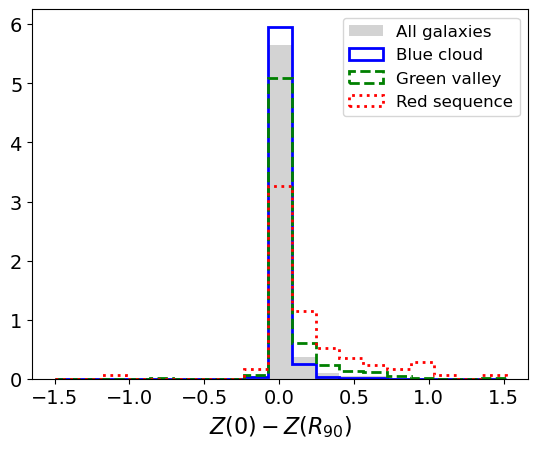

In [288]:
z_bins = np.linspace(-1.5, np.max(master_table['delta_z']), 20)

plt.hist(master_table['delta_z'], density=1, bins=z_bins, 
         color='lightgrey', label='All galaxies')

plt.hist(master_table['delta_z'][master_table['CMD_class']==1], density=1, bins=z_bins, 
         color='b', histtype='step', linewidth=2, label='Blue cloud')

plt.hist(master_table['delta_z'][master_table['CMD_class']==2], density=1, bins=z_bins, 
         color='g', histtype='step', linewidth=2, linestyle='--', label='Green valley')

plt.hist(master_table['delta_z'][master_table['CMD_class']==3], density=1, bins=z_bins, 
         color='r', histtype='step', linewidth=2, linestyle=':', label='Red sequence')

plt.tick_params(labelsize=14)
plt.xlabel(r'$Z(0) - Z(R_{90})$', fontsize=16)
plt.legend(fontsize='large')

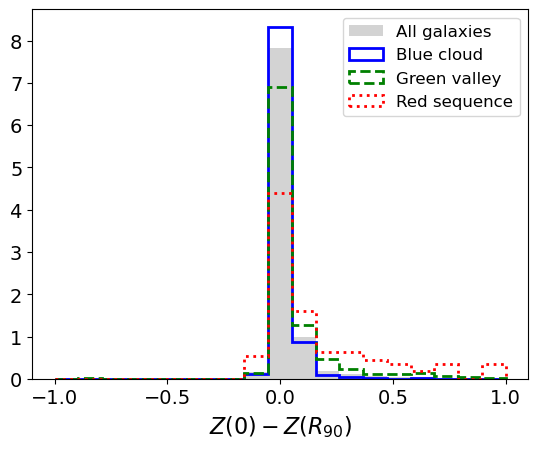

In [289]:
z_bins = np.linspace(-1, 1, 20)

plt.hist(master_table['delta_z'], density=1, bins=z_bins, 
         color='lightgrey', label='All galaxies')

plt.hist(master_table['delta_z'][master_table['CMD_class']==1], density=1, bins=z_bins, 
         color='b', histtype='step', linewidth=2, label='Blue cloud')

plt.hist(master_table['delta_z'][master_table['CMD_class']==2], density=1, bins=z_bins, 
         color='g', histtype='step', linewidth=2, linestyle='--', label='Green valley')

plt.hist(master_table['delta_z'][master_table['CMD_class']==3], density=1, bins=z_bins, 
         color='r', histtype='step', linewidth=2, linestyle=':', label='Red sequence')

plt.tick_params(labelsize=14)
plt.xlabel(r'$Z(0) - Z(R_{90})$', fontsize=16)
plt.legend(fontsize='large')

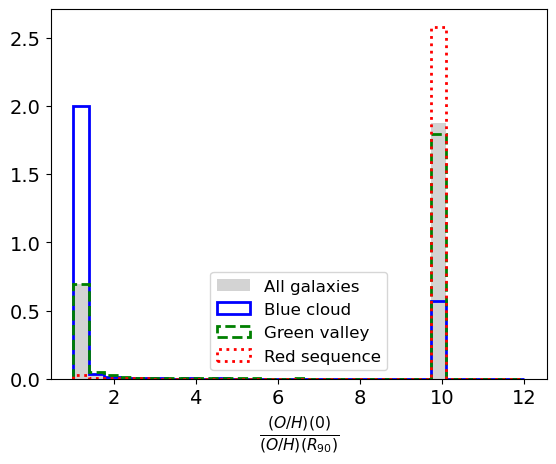

In [345]:
z_bins = np.linspace(1, 12, 30)

plt.hist(10**master_table['delta_z'], density=1, bins=z_bins, 
         color='lightgrey', label='All galaxies')

plt.hist(10**master_table['delta_z'][master_table['CMD_class']==1], density=1, bins=z_bins, 
         color='b', histtype='step', linewidth=2, label='Blue cloud')

plt.hist(10**master_table['delta_z'][master_table['CMD_class']==2], density=1, bins=z_bins, 
         color='g', histtype='step', linewidth=2, linestyle='--', label='Green valley')

plt.hist(10**master_table['delta_z'][master_table['CMD_class']==3], density=1, bins=z_bins, 
         color='r', histtype='step', linewidth=2, linestyle=':', label='Red sequence')

plt.tick_params(labelsize=14)
plt.xlabel(r'$\frac{(O/H)(0)}{(O/H)(R_{90})}$', fontsize=16)
plt.legend(fontsize='large')

## delta z vs mr

In [309]:
blue = master_table[master_table['CMD_class']==1]
green = master_table[master_table['CMD_class']==2]
red = master_table[master_table['CMD_class']==3]


In [333]:
bins = np.linspace(-16,-23,10)
pts = (bins[:-1] + bins [1:]) / 2
b_dz = []
g_dz = []
r_dz = []
b_ctrs =[]
g_ctrs = []
r_ctrs = []

b_indices = np.digitize(blue['rabsmag'], bins, right=True)
g_indices = np.digitize(green['rabsmag'], bins, right=True)
r_indices = np.digitize(red['rabsmag'], bins, right=True)


In [334]:
for i in range(1,len(bins)):

    b_dz.append(blue['delta_z'][b_indices==i])
    b_ctrs.append(ma.mean(blue['rabsmag'][b_indices==i]))

    g_dz.append(green['delta_z'][g_indices==i])
    g_ctrs.append(ma.mean(green['rabsmag'][g_indices==i]))

    r_dz.append(red['delta_z'][r_indices==i])
    r_ctrs.append(ma.mean(red['rabsmag'][r_indices==i]))

In [335]:
b_meds = np.ones(len(pts))*np.nan
g_meds = np.ones(len(pts))*np.nan
r_meds = np.ones(len(pts))*np.nan

for i in range(len(pts)):

    b_meds[i] = ma.median(b_dz[i])
    g_meds[i] = ma.median(g_dz[i])
    r_meds[i] = ma.median(r_dz[i])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_49333/304745110.py:7: UserWarning: Warning: converting a masked element to nan.
  b_meds[i] = ma.median(b_dz[i])
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_49333/304745110.py:9: UserWarning: Warning: converting a masked element to nan.
  r_meds[i] = ma.median(r_dz[i])


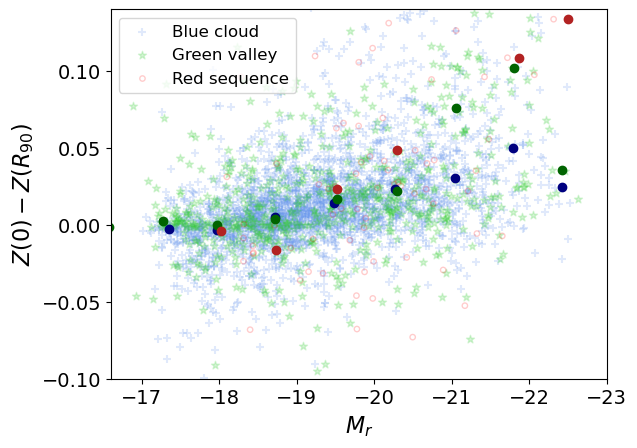

In [340]:
# plt.scatter(master_table['rabsmag'], master_table['delta_z'], color='lightgrey')
plt.scatter(master_table['rabsmag'][master_table['CMD_class']==1], master_table['delta_z'][master_table['CMD_class']==1], 
           color='cornflowerblue', marker='+',  label='Blue cloud', alpha=0.2)
plt.scatter(master_table['rabsmag'][master_table['CMD_class']==2], master_table['delta_z'][master_table['CMD_class']==2], 
           color='limegreen', marker='*',  label='Green valley', alpha=0.2)
plt.scatter(master_table['rabsmag'][master_table['CMD_class']==3], master_table['delta_z'][master_table['CMD_class']==3], 
           color='r', facecolor='none', marker='o', s=15,  label='Red sequence', alpha=0.2)



plt.scatter(b_ctrs, b_meds, color='navy')
plt.scatter(g_ctrs, g_meds, color='darkgreen')
plt.scatter(r_ctrs, r_meds, color='firebrick')


plt.xlim(-16.6,-23)
plt.ylim(-0.1,0.14)


plt.tick_params(labelsize=14)
plt.ylabel(r'$Z(0) - Z(R_{90})$', fontsize=16)
plt.xlabel(r'$M_r$', fontsize=16)
plt.legend(fontsize='large', loc='upper left')

In [341]:
bins = np.linspace(-16,-23,10)
pts = (bins[:-1] + bins [1:]) / 2
b_dz = []
g_dz = []
r_dz = []
b_ctrs =[]
g_ctrs = []
r_ctrs = []

b_indices = np.digitize(blue['rabsmag'], bins, right=True)
g_indices = np.digitize(green['rabsmag'], bins, right=True)
r_indices = np.digitize(red['rabsmag'], bins, right=True)


for i in range(1,len(bins)):

    b_dz.append(10**blue['delta_z'][b_indices==i])
    b_ctrs.append(ma.mean(blue['rabsmag'][b_indices==i]))

    g_dz.append(10**green['delta_z'][g_indices==i])
    g_ctrs.append(ma.mean(green['rabsmag'][g_indices==i]))

    r_dz.append(10**red['delta_z'][r_indices==i])
    r_ctrs.append(ma.mean(red['rabsmag'][r_indices==i]))


b_meds = np.ones(len(pts))*np.nan
g_meds = np.ones(len(pts))*np.nan
r_meds = np.ones(len(pts))*np.nan

for i in range(len(pts)):

    b_meds[i] = ma.median(b_dz[i])
    g_meds[i] = ma.median(g_dz[i])
    r_meds[i] = ma.median(r_dz[i])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_49333/1269371531.py:33: UserWarning: Warning: converting a masked element to nan.
  b_meds[i] = ma.median(b_dz[i])
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_49333/1269371531.py:35: UserWarning: Warning: converting a masked element to nan.
  r_meds[i] = ma.median(r_dz[i])


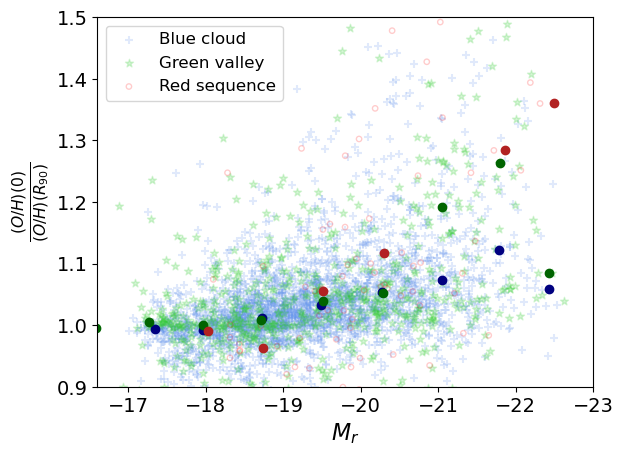

In [346]:
# plt.scatter(master_table['rabsmag'], master_table['delta_z'], color='lightgrey')
plt.scatter(master_table['rabsmag'][master_table['CMD_class']==1], 10**master_table['delta_z'][master_table['CMD_class']==1], 
           color='cornflowerblue', marker='+',  label='Blue cloud', alpha=0.2)
plt.scatter(master_table['rabsmag'][master_table['CMD_class']==2], 10**master_table['delta_z'][master_table['CMD_class']==2], 
           color='limegreen', marker='*',  label='Green valley', alpha=0.2)
plt.scatter(master_table['rabsmag'][master_table['CMD_class']==3], 10**master_table['delta_z'][master_table['CMD_class']==3], 
           color='r', facecolor='none', marker='o', s=15,  label='Red sequence', alpha=0.2)



plt.xlim(-16.6,-23)
plt.ylim(0.9,1.5)
# plt.yscale('log')

plt.scatter(b_ctrs, b_meds, color='navy')
plt.scatter(g_ctrs, g_meds, color='darkgreen')
plt.scatter(r_ctrs, r_meds, color='firebrick')


plt.tick_params(labelsize=14)
plt.ylabel(r'$\frac{(O/H)(0)}{(O/H)(R_{90})}$', fontsize=16)
plt.xlabel(r'$M_r$', fontsize=16)
plt.legend(fontsize='large', loc='upper left')

## delta z vs stellar age

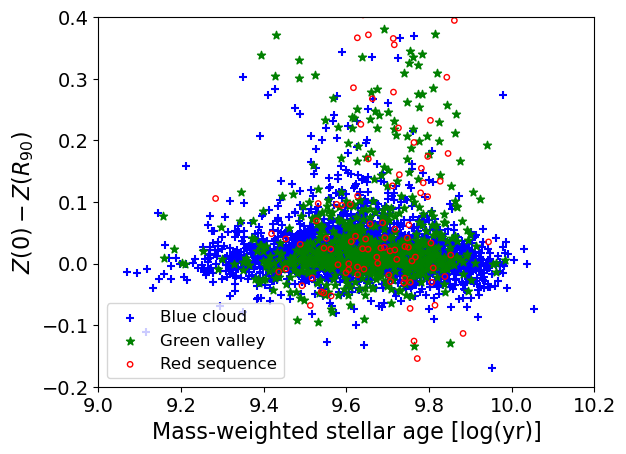

In [347]:
# plt.scatter(master_table['Age_MW_Re_fit'],master_table['delta_z'],  color='lightgrey')
plt.scatter(master_table['Age_MW_Re_fit'][master_table['CMD_class']==1], master_table['delta_z'][master_table['CMD_class']==1], 
           color='b', marker='+',  label='Blue cloud')
plt.scatter(master_table['Age_MW_Re_fit'][master_table['CMD_class']==2], master_table['delta_z'][master_table['CMD_class']==2], 
           color='g', marker='*',  label='Green valley')
plt.scatter(master_table['Age_MW_Re_fit'][master_table['CMD_class']==3], master_table['delta_z'][master_table['CMD_class']==3], 
           color='r', facecolor='none', marker='o', s=15,  label='Red sequence')



plt.xlim(9,10.2)
plt.ylim(-0.2,0.4)

plt.tick_params(labelsize=14)
plt.ylabel(r'$Z(0) - Z(R_{90})$', fontsize=16)
plt.xlabel(r'Mass-weighted stellar age [log(yr)]', fontsize=16)
plt.legend(fontsize='large', )

## bulge vs disk mass

In [348]:
master_table['M_disk'] = np.ones(len(master_table))*np.nan
master_table['M_bulge'] = np.ones(len(master_table))*np.nan

In [349]:
for i in tqdm(range(len(master_table))):

    # spiral
    if master_table['Sigma_disk'][i] > 0:

        # convert everything to Msun/kpc ^2,3 or kpc

        Sig_d = master_table['Sigma_disk'][i] * 1000**2
        R_d = master_table['R_disk'][i] 
        rho_b = master_table['rho_bulge'][i]
        R_b = master_table['R_bulge'][i]
        
    # elliptical
    elif master_table['sphd_rho_c'][i] > 0:

        Sig_d = 10**master_table['sphd_Sigma_d'][i] * 1000**2
        R_d = master_table['sphd_R_d'][i]
        rho_b = 10**master_table['sphd_rho_c'][i]
        R_b = master_table['sphd_R_scale'][i]
        


    master_table['M_disk'][i] = np.log10(2 * np.pi * Sig_d * R_d**2)
    master_table['M_bulge'][i] = np.log10(8 * np.pi * R_b**4 * rho_b)

100%|███████| 11273/11273 [00:00<00:00, 29866.13it/s]


In [350]:
master_table[5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot,kias_u_r,kias_cinv,kias_cd,delta_z,M_bulge
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float

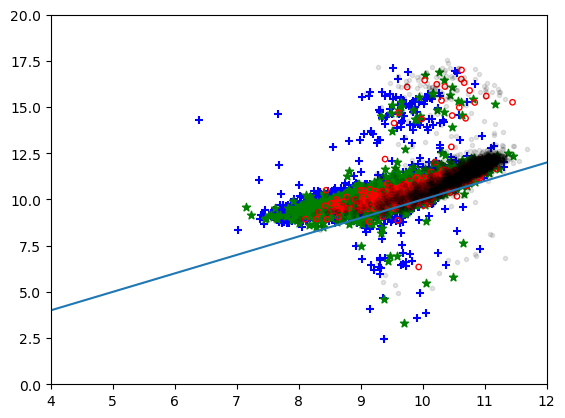

In [351]:
# plt.scatter(master_table['M_disk'], master_table['M_bulge'])
plt.scatter(master_table['M_disk'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==1)], 
            master_table['M_bulge'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==1)],
           color='b', marker='+')

plt.scatter(master_table['M_disk'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==2)], 
            master_table['M_bulge'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==2)],
           color='g', marker='*')

plt.scatter(master_table['M_disk'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==3)], 
            master_table['M_bulge'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==3)],
           color='r', marker='o', s=15, facecolor='none')

plt.scatter(master_table['M_disk'][master_table['elliptical_mask'] == 1], 
            master_table['M_bulge'][master_table['elliptical_mask'] == 1],
           color='k', marker='.', alpha=0.1)

plt.xlim(4,12)
plt.ylim(0,20)

plt.plot([4,20],[4,20])

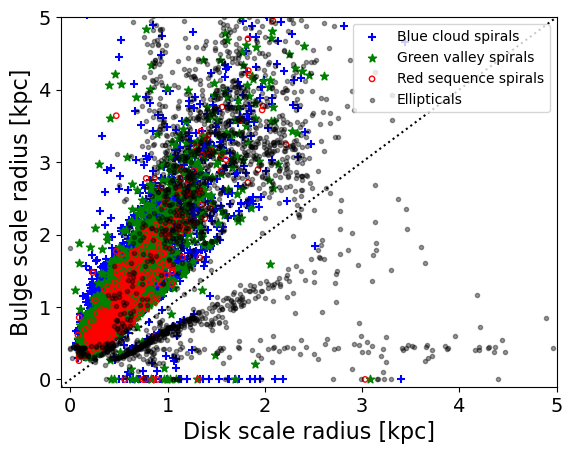

In [352]:
# plt.scatter(master_table['M_disk'], master_table['M_bulge'])
plt.scatter(master_table['R_disk'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==1)], 
            master_table['R_bulge'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==1)],
           color='b', marker='+', label='Blue cloud spirals')

plt.scatter(master_table['R_disk'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==2)], 
            master_table['R_bulge'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==2)],
           color='g', marker='*', label = 'Green valley spirals')

plt.scatter(master_table['R_disk'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==3)], 
            master_table['R_bulge'][(master_table['spiral_mask'] ==1) & (master_table['CMD_class']==3)],
           color='r', marker='o', s=15, facecolor='none', label='Red sequence spirals')

plt.scatter(master_table['sphd_R_d'][master_table['elliptical_mask'] == 1], 
            master_table['sphd_R_scale'][master_table['elliptical_mask'] == 1],
           color='k', marker='.', alpha=0.4, label='Ellipticals')

plt.xlim(-0.1,5)
plt.ylim(-0.1,5)

plt.plot([-0.1,5],[-0.1,5], 'k:')

plt.xlabel('Disk scale radius [kpc]', fontsize=16)

plt.ylabel('Bulge scale radius [kpc]', fontsize=16)
plt.tick_params(labelsize=14)

plt.legend()

## ratio of components vs. delta z

In [353]:
master_table['R_d_R_b'] = np.ones(len(master_table))*np.nan

for i in range(len(master_table)):

    # spirals
    if master_table['R_disk'][i] > 0:

        master_table['R_d_R_b'][i] = master_table['R_disk'][i]/master_table['R_bulge'][i]

    # ellipticals
    elif master_table['sphd_R_scale'][i] > 0:

        master_table['R_d_R_b'][i] =  master_table['sphd_R_d'][i]/master_table['sphd_R_scale'][i]

Text(0, 0.5, '$\\Delta\\, Z$')

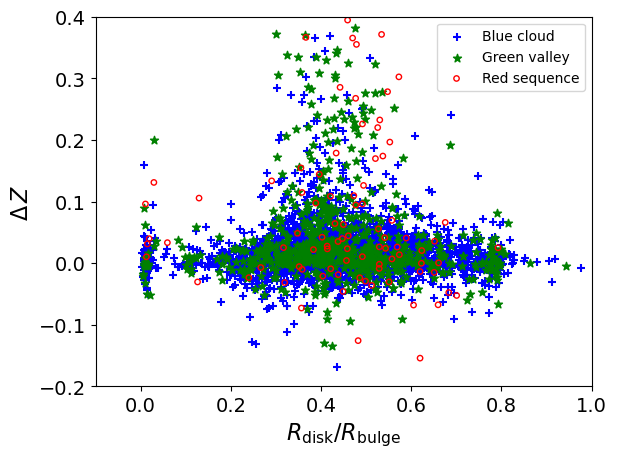

In [354]:
# plt.scatter(master_table['R_d_R_b'], master_table['delta_z'])

plt.scatter(master_table['R_d_R_b'][master_table['CMD_class']==1], master_table['delta_z'][master_table['CMD_class']==1],
           color='b', marker='+', label='Blue cloud')

plt.scatter(master_table['R_d_R_b'][master_table['CMD_class']==2], master_table['delta_z'][master_table['CMD_class']==2],
           color='g', marker='*', label='Green valley')

plt.scatter(master_table['R_d_R_b'][master_table['CMD_class']==3], master_table['delta_z'][master_table['CMD_class']==3],
           color='r', marker='o', label='Red sequence', facecolor='none', s=15)

# plt.scatter(master_table['R_d_R_b'][master_table['Mvir']>0], master_table['delta_z'][master_table['Mvir']>0],
#            color='k', marker='o', label='Ellipticals')




plt.ylim(-0.2,0.4)
plt.xlim(-0.1,1)

plt.legend()

plt.tick_params(labelsize=14)
plt.xlabel(r'$R_{\rm disk}/R_{\rm bulge}$', fontsize=16)
plt.ylabel(r'$\Delta\, Z$', fontsize=16)

## u -r color (nsa) vs. Rd/Rb

Text(0.5, 0, '$u-r$ (KIAS)')

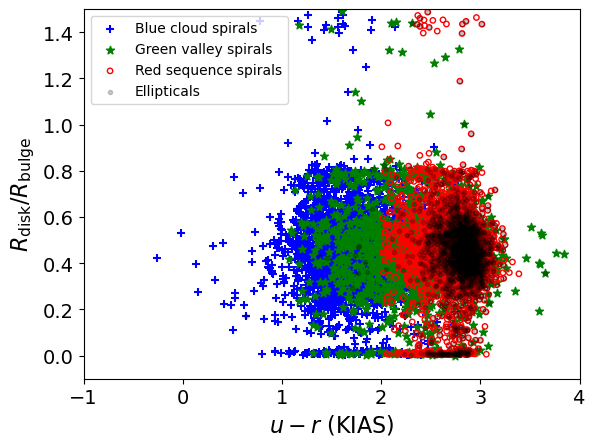

In [270]:
# plt.scatter(master_table['R_d_R_b'], master_table['delta_z'])

plt.scatter(master_table['kias_u_r'][master_table['CMD_class']==1], master_table['R_d_R_b'][master_table['CMD_class']==1],
           color='b', marker='+', label='Blue cloud spirals')

plt.scatter(master_table['kias_u_r'][master_table['CMD_class']==2], master_table['R_d_R_b'][master_table['CMD_class']==2],
           color='g', marker='*', label='Green valley spirals')

plt.scatter(master_table['kias_u_r'][master_table['CMD_class']==3], master_table['R_d_R_b'][master_table['CMD_class']==3],
           color='r', marker='o', label='Red sequence spirals', facecolor='none', s=15)

plt.scatter(master_table['kias_u_r'][master_table['Mvir']>0], master_table['R_d_R_b'][master_table['Mvir']>0],
           color='k', marker='.', label='Ellipticals', alpha=0.2)




plt.ylim(-0.1,1.5)
plt.xlim(-1,4)

plt.legend()

plt.tick_params(labelsize=14)
plt.ylabel(r'$R_{\rm disk}/R_{\rm bulge}$', fontsize=16)
plt.xlabel(r'$u-r$ (KIAS)', fontsize=16)

## u - r color (nsa) vs. delta z

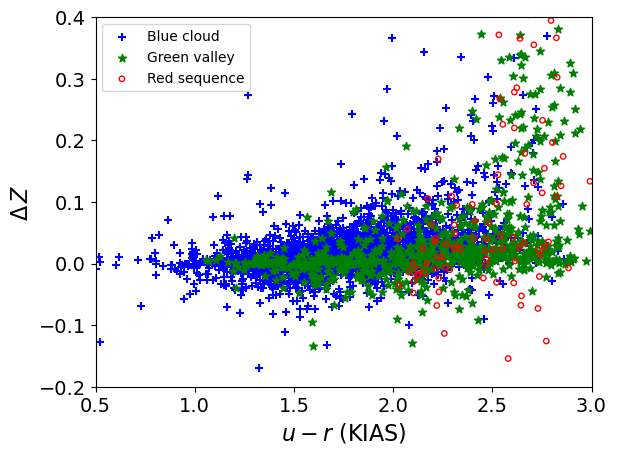

In [355]:
# plt.scatter(master_table['nsa_u_r'], master_table['delta_z'])

plt.scatter(master_table['kias_u_r'][master_table['CMD_class']==1], master_table['delta_z'][master_table['CMD_class']==1],
           color='b', marker='+', label='Blue cloud')


plt.scatter(master_table['kias_u_r'][master_table['CMD_class']==2], master_table['delta_z'][master_table['CMD_class']==2],
           color='g', marker='*', label='Green valley')


plt.scatter(master_table['kias_u_r'][master_table['CMD_class']==3], master_table['delta_z'][master_table['CMD_class']==3],
           color='r', marker='o', facecolor='none', s=15, label='Red sequence')

plt.ylim(-0.2,0.4)
plt.xlim(0.5, 3)

plt.xlabel(r'$u-r$ (KIAS)', fontsize=16)
plt.ylabel(r'$\Delta \, Z$', fontsize=16)

plt.tick_params(labelsize=14)

plt.legend()

## VS. cinv

Text(0.5, 0, '$c_{\\rm inv}$ (KIAS)')

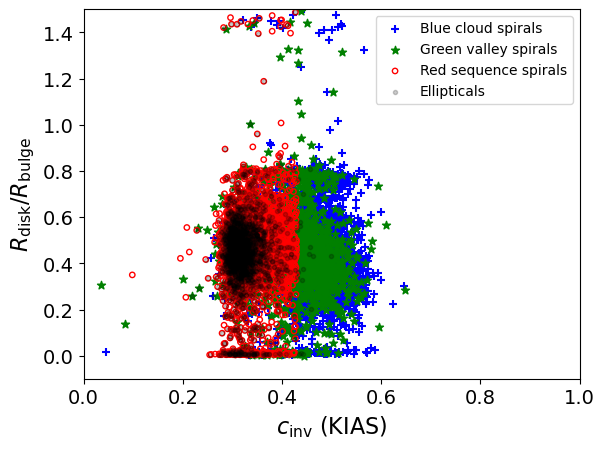

In [272]:
# plt.scatter(master_table['R_d_R_b'], master_table['delta_z'])

plt.scatter(master_table['kias_cinv'][master_table['CMD_class']==1], master_table['R_d_R_b'][master_table['CMD_class']==1],
           color='b', marker='+', label='Blue cloud spirals')

plt.scatter(master_table['kias_cinv'][master_table['CMD_class']==2], master_table['R_d_R_b'][master_table['CMD_class']==2],
           color='g', marker='*', label='Green valley spirals')

plt.scatter(master_table['kias_cinv'][master_table['CMD_class']==3], master_table['R_d_R_b'][master_table['CMD_class']==3],
           color='r', marker='o', label='Red sequence spirals', facecolor='none', s=15)

plt.scatter(master_table['kias_cinv'][master_table['Mvir']>0], master_table['R_d_R_b'][master_table['Mvir']>0],
           color='k', marker='.', label='Ellipticals', alpha=0.2)




plt.ylim(-0.1,1.5)
plt.xlim(0,1)

plt.legend()

plt.tick_params(labelsize=14)
plt.ylabel(r'$R_{\rm disk}/R_{\rm bulge}$', fontsize=16)
plt.xlabel(r'$c_{\rm inv}$ (KIAS)', fontsize=16)

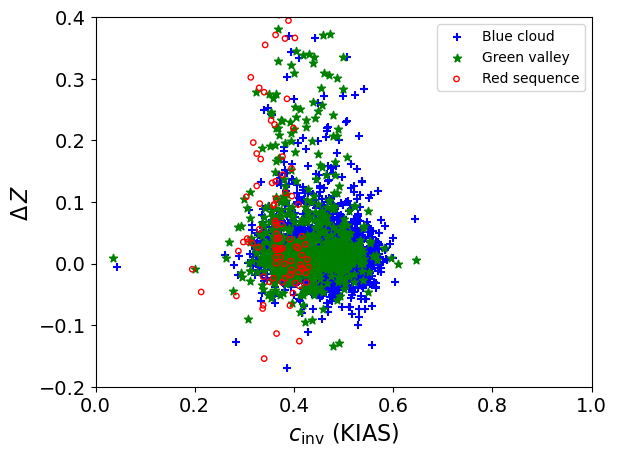

In [356]:
# plt.scatter(master_table['nsa_u_r'], master_table['delta_z'])

plt.scatter(master_table['kias_cinv'][master_table['CMD_class']==1], master_table['delta_z'][master_table['CMD_class']==1],
           color='b', marker='+', label='Blue cloud')


plt.scatter(master_table['kias_cinv'][master_table['CMD_class']==2], master_table['delta_z'][master_table['CMD_class']==2],
           color='g', marker='*', label='Green valley')


plt.scatter(master_table['kias_cinv'][master_table['CMD_class']==3], master_table['delta_z'][master_table['CMD_class']==3],
           color='r', marker='o', facecolor='none', s=15, label='Red sequence')

plt.ylim(-0.2,0.4)
plt.xlim(0, 1)

plt.xlabel(r'$c_{\rm inv}$ (KIAS)', fontsize=16)
plt.ylabel(r'$\Delta \, Z$', fontsize=16)

plt.tick_params(labelsize=14)

plt.legend()